In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
tf.config.optimizer.set_jit(True)  # Enable XLA

E0000 00:00:1746005098.044185     473 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746005098.063095     473 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import pandas as pd
import numpy as np
import json
from glob import glob
import utils_glob_stats

In [3]:
from sklearn.model_selection import KFold
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             hamming_loss, f1_score, roc_auc_score)

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras import backend as K
from keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
import gc

from tensorflow.keras.mixed_precision import set_global_policy
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print("Mixed precision enabled with policy:", policy.name)

Mixed precision enabled with policy: mixed_float16


In [4]:
import utils_glob_stats

# Load global statistics with utils
label_frequencies = utils_glob_stats.load_class_weights(segment_length=10)

global_stats = utils_glob_stats.load_global_stats(segment_length=10)

time_axis_stats = utils_glob_stats.load_time_axis_stats(segment_length=10)

I0000 00:00:1746005102.793757     473 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
total = label_frequencies['total_examples']
class_weights_combined = label_frequencies['combined_weights_numpy']
class_weights_tf = tf.constant(class_weights_combined, dtype=tf.float32) #convert to tensor for focal loss

mean_global = global_stats['mean']
std_global = global_stats['std']

mean_axis_time_global = time_axis_stats['mean']

print('Total training examples, ', total)
print('Spectrogram mean, ', mean_global)
print('Spectrogram std, ', std_global)
print('Mean time axis val, ', mean_axis_time_global)
print('Class weights, ', class_weights_combined)

Total training examples,  70078
Spectrogram mean,  -38.622053581065884
Spectrogram std,  13.92796650578306
Mean time axis val,  432
Class weights,  [[0.19714070306078363, 0.34159062547412294], [0.14197785989591272, 1.0453162289922056], [0.1832123734588971, 0.3934137249441564], [0.1594014994329912, 0.5791953186604605], [0.18091928621213352, 0.4044205909323905], [0.14573351300749096, 0.878610832409367], [0.1613689116468689, 0.554625174081637], [0.1319795998292657, 2.3636670258058103]]


### Helper functions to load the dataset

In [6]:
def get_feature_description():
    feature_description = {
        'mel': tf.io.FixedLenFeature([], tf.string),
        'labels': tf.io.VarLenFeature(tf.int64),
        'song': tf.io.FixedLenFeature([], tf.string),
        'segment_idx': tf.io.FixedLenFeature([], tf.int64),
        'total_segments': tf.io.FixedLenFeature([], tf.int64),
    }
    return feature_description

In [7]:
def get_song_id(file):
    ds = tf.data.TFRecordDataset(file)
    feat = {'song': tf.io.FixedLenFeature([], tf.string)}
    raw = next(iter(ds))
    parsed = tf.io.parse_single_example(raw, feat)
    return parsed['song'].numpy().decode('utf-8')

In [8]:
def get_labels(file):
    dataset = tf.data.TFRecordDataset(file)
    for example in dataset.take(1):
        parsed = tf.io.parse_single_example(example, get_feature_description())
        labels = tf.sparse.to_dense(parsed['labels']).numpy()
    return labels

In [9]:
def parse_tfrecord_fn(example):
    feature_description = get_feature_description()
    example = tf.io.parse_single_example(example, feature_description)
    
    # Directly parse the float32 tensor
    mel_spec = tf.io.parse_tensor(example['mel'], out_type=tf.float32)
    
    current_shape = tf.shape(mel_spec)
    
    if tf.rank(mel_spec) != 2:
        # If not a 2D tensor, reshape it to [80, ?]
        mel_spec = tf.reshape(mel_spec, [96, -1])
        current_shape = tf.shape(mel_spec)
    
    # Crop or pad the time dimension to mean_axis_time_global
    if current_shape[1] > mean_axis_time_global:
        # Crop to [80, mean]
        mel_spec = mel_spec[:, :mean_axis_time_global]
    else:
        # Pad to [80, mean]
        paddings = [[0, 0], [0, mean_axis_time_global - current_shape[1]]]
        mel_spec = tf.pad(mel_spec, paddings, "CONSTANT", constant_values=0)
    
    mel_spec = tf.ensure_shape(mel_spec, [96, mean_axis_time_global])
    # normalization
    mel_spec = (mel_spec - mean_global) / (std_global + 1e-6)
    
    # Add channel dimension for CNN input [80, mean] -> [80, mean, 1]
    mel_spec = tf.expand_dims(mel_spec, axis=-1)
    
    labels = tf.sparse.to_dense(example['labels'])
    labels = tf.ensure_shape(labels, [8])
    
    return mel_spec, labels

In [10]:
def prepare_dataset(tfrecord_pattern, batch_size=32, is_training=True, aux=False):
    
    dataset = tf.data.Dataset.list_files(tfrecord_pattern, shuffle=is_training)
    
    dataset = dataset.interleave(
        tf.data.TFRecordDataset,
        cycle_length=6,
        num_parallel_calls=6,
        deterministic= False
    )
    
    dataset = dataset.map(parse_tfrecord_fn, num_parallel_calls=8)
    #dataset = dataset.cache()  # Cache after parsing but before augmentation
    
    if is_training:
        # Apply enhanced augmentation for training data
        dataset = dataset.map(augment, num_parallel_calls=8)
        dataset = dataset.shuffle(50000)

    dataset = dataset.batch(batch_size, drop_remainder=is_training)

    if is_training:
        dataset = dataset.repeat()
    
    dataset = dataset.prefetch(1)
    
    return dataset

In [11]:
def stretch_mel_time_axis(mel, factor_range=(0.9, 1.1)):
    factor = tf.random.uniform([], factor_range[0], factor_range[1])
    time_steps = tf.cast(tf.shape(mel)[1], tf.float32)
    new_time_steps = tf.cast(time_steps * factor, tf.int32)
    mel = tf.image.resize(mel, size=[tf.shape(mel)[0], new_time_steps])
    mel = tf.image.resize_with_crop_or_pad(mel, 80, mean_axis_time_global)
    return mel

In [12]:
def time_mask(x, max_frames=40):
    """zero-out a random consecutive time stripe"""
    T  = tf.shape(x)[1]
    t  = tf.random.uniform([], 0, max_frames, tf.int32)
    t0 = tf.random.uniform([], 0, T - t,      tf.int32)
    zeros = tf.zeros_like(x[:, t0:t0+t, :])
    return tf.concat([x[:, :t0, :], zeros, x[:, t0+t:, :]], axis=1)

In [13]:
def freq_mask(x, max_bins=16):
    """zero-out a random consecutive mel-bin stripe"""
    F  = tf.shape(x)[0]
    f  = tf.random.uniform([], 0, max_bins, tf.int32)
    f0 = tf.random.uniform([], 0, F - f,      tf.int32)
    zeros = tf.zeros_like(x[f0:f0+f, :, :])
    return tf.concat([x[:f0, :, :], zeros, x[f0+f:, :, :]], axis=0)

In [14]:
def random_gain(x, min_gain=0.9, max_gain=1.1):
    '''small volume-like tweaks'''
    gain = tf.random.uniform([], min_gain, max_gain)
    return x * gain

In [15]:
def random_time_shift(x, max_shift=10):
    '''roll time axis and wrap it around'''
    shift = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    return tf.roll(x, shift=shift, axis=1)

In [16]:
def augment(m, labels):
    orig_e = tf.reduce_mean(tf.square(m))
    T = tf.shape(m)[1]

    # — Time Mask —
    def do_time_mask():
        for _ in range(tf.random.uniform([], 1, 3, dtype=tf.int32)):
            max_time_mask = tf.random.uniform([], minval=20, maxval=120, dtype=tf.int32)
            mm = time_mask(m, max_time_mask)
        e = tf.reduce_mean(tf.square(mm))
        return mm * tf.sqrt(orig_e / (e + 1e-8))
    m = tf.cond(
        tf.random.uniform([]) < 0.9,
        true_fn=do_time_mask,
        false_fn=lambda: m
    )

    # — Freq Mask —
    def do_freq_mask():
        for _ in range(tf.random.uniform([], 1, 3, dtype=tf.int32)):
            max_freq_mask = tf.random.uniform([], minval=10, maxval=40, dtype=tf.int32)
            mm = freq_mask(m, max_freq_mask)
        e = tf.reduce_mean(tf.square(mm))
        return mm * tf.sqrt(orig_e / (e + 1e-8))
    m = tf.cond(
        tf.random.uniform([]) < 0.8,
        true_fn=do_freq_mask,
        false_fn=lambda: m
    )

    # — Random Gain —
    def do_gain():
        return random_gain(m, 0.8, 1.2)
    m = tf.cond(
        tf.random.uniform([]) < 0.7,
        true_fn=do_gain,
        false_fn=lambda: m
    )

    # — Time Shift —
    m = tf.cond(
        tf.random.uniform([]) < 0.6,
        true_fn=lambda: random_time_shift(m, max_shift=10),
        false_fn=lambda: m
    )

    # — Noise + Renorm —
    def do_noise():
        std = tf.random.uniform([], 0.1/2, 0.1)
        mm = m + tf.random.normal(tf.shape(m), 0., std, dtype=m.dtype)
        e = tf.reduce_mean(tf.square(mm))
        return mm * tf.sqrt(orig_e / (e + 1e-8))
    m = tf.cond(
        tf.random.uniform([]) < 0.8,
        true_fn=do_noise,
        false_fn=lambda: m
    )

    # — Time Crop + Renorm + Pad —
    def do_crop():
        min_win = tf.cast(0.25 * tf.cast(T, tf.float32), tf.int32)
        win = tf.random.uniform([], minval=min_win, maxval=T, dtype=tf.int32)
        start = tf.random.uniform([], 0, T - win, dtype=tf.int32)
        cm = m[:, start:start + win, :]
        e = tf.reduce_mean(tf.square(cm))
        cm = cm * tf.sqrt(orig_e / (e + 1e-8))
        return tf.pad(cm, [[0,0], [0, T - win], [0,0]])
    m = tf.cond(
        tf.random.uniform([]) < 0.5,
        true_fn=do_crop,
        false_fn=lambda: m
    )

    # ensure shape
    m = tf.ensure_shape(m, [96, mean_axis_time_global, 1])
    return m, labels

### Model Architecture

In [17]:
from tensorflow.keras.activations import swish

In [18]:
class BiasLayer(layers.Layer):
    def build(self, input_shape):
        # input_shape = (batch, num_classes)
        self.bias = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True,
            name="class_bias"
        )
    def call(self, inputs):
        return inputs + self.bias

In [19]:
# 3D Attention layer for sequence data
def attention_layer(x):
    # channel (feature) attention
    avg_pool = layers.GlobalAveragePooling1D()(x) # (batch, features)
    max_pool = layers.GlobalMaxPooling1D()(x) # (batch, features)
    concat = layers.Concatenate()([avg_pool, max_pool]) # (batch, 2*features)
    dense = layers.Dense(x.shape[-1], activation='sigmoid')(concat)
    attn = layers.Multiply()([x, layers.Reshape((1, x.shape[-1]))(dense)])
    return attn

In [20]:
def residual_block(x, filters, stride=(1,1), use_dropout=False, regularization=0.0):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding='same',
                      kernel_regularizer=regularizers.l2(regularization))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if use_dropout:
        x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_regularizer=regularizers.l2(regularization))(x)
    x = layers.BatchNormalization()(x)
    if stride != (1,1) or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [21]:
def hybrid_CNN_BiLSTM_V0(input_shape, num_classes=8, dropout_rate=0.3):
    inputs = layers.Input(shape=input_shape)  # e.g. (96, 432, 1)

    # conv -> pool -> dropout
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((3,4))(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(32, 3, strides= (1, 2), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2,4))(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2,4))(x)
    x = layers.Dropout(dropout_rate)(x)

    # Flatten spatial to sequence for RNN
    t, f, c = x.shape[1], x.shape[2], x.shape[3] # batch, time_steps, features
    seq = layers.Permute((2,1,3))(x)
    seq = layers.Reshape((f, t*c))(seq)

    # 3) BiLSTM
    seq = layers.Bidirectional(layers.LSTM(44, return_sequences=True))(seq)
    
    # 4) Pool & head
    out = layers.GlobalAveragePooling1D()(seq)
    out = layers.Dropout(dropout_rate)(out)
    outputs = layers.Dense(num_classes, activation='sigmoid')(out)

    return models.Model(inputs, outputs, name="hybrid_CNN_BiLSTM_V0")

In [54]:
def hybrid_CNN_BiLSTM_V1(input_shape, num_classes=8, dropout_rate=0.3):
    inputs = layers.Input(shape=input_shape)  # e.g. (96, 432, 1)

    # conv -> pool -> dropout
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2,4))(x)
    x = layers.Dropout(dropout_rate)(x)

    # Flatten spatial to sequence for RNN
    t, f, c = x.shape[1], x.shape[2], x.shape[3] # batch, time_steps, features
    seq = layers.Permute((2,1,3))(x)
    seq = layers.Reshape((f, t*c))(seq)

    # 3) BiLSTM + self-attention
    seq = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(seq)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=16)(seq, seq)
    attn = layers.Dropout(dropout_rate)(attn)

    # 4) Pool & head
    out = layers.GlobalAveragePooling1D()(attn)
    out = layers.Dropout(dropout_rate)(out)
    outputs = layers.Dense(num_classes, activation='sigmoid')(out)

    return models.Model(inputs, outputs, name="hybrid_CNN_BiLSTM_V1")

In [23]:
def hybrid_CNN_BiLSTM_V2(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Conv Backbone
    x = layers.Conv2D(32, 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.MaxPooling2D((2,4))(x)
    x = layers.Dropout(0.1)(x)

    # res 1
    x = residual_block(x, 64, use_dropout=True, regularization=1e-6)
    x = layers.MaxPooling2D((2,3))(x)

    # res 2
    x = residual_block(x, 96, stride=2, regularization=1e-5)
    x = layers.Dropout(0.25)(x)

    # res 3
    x = residual_block(x, 128, stride=2)
    x = layers.Dropout(0.3)(x)

    # RNN + Attention Branch
    # reshape (batch, time=W, features=H*C)
    H, W, C = x.shape[1], x.shape[2], x.shape[3]
    seq = layers.Reshape((W, H*C))(layers.Permute((2,1,3))(x))
    rnn = layers.Bidirectional(layers.LSTM(50, return_sequences=True))(seq)
    rnn = layers.Dropout(0.25)(rnn)
    # attention weights
    attn_scores = layers.Dense(1)(rnn)
    attn_scores = layers.Softmax(axis=1)(attn_scores)
    # context vector
    rnn_ctx = layers.Lambda(lambda z: tf.reduce_sum(z[0] * z[1], axis=1))([rnn, attn_scores])

    # Merge & Final Heads
    conv_feat = layers.GlobalAveragePooling2D()(x)
    merged    = layers.Concatenate()([conv_feat, rnn_ctx])

    m = layers.Dense(512, use_bias=False,
                     kernel_regularizer=regularizers.l2(5e-4))(merged)
    m = layers.BatchNormalization()(m)
    m = layers.ReLU()(m)
    m = layers.Dropout(0.45)(m)

    m = layers.Dense(128, activation='gelu',
                     kernel_regularizer=regularizers.l2(3e-4))(m)
    m = layers.Dropout(0.15)(m)

    outputs = layers.Dense(num_classes, activation='sigmoid',
                              name='binary_output')(m)

    return models.Model(inputs, outputs, name="hybrid_CNN_BiLSTM_V2")

In [24]:
def cbam_block(x, ratio=8):
    # Channel‐attention
    channel   = x.shape[-1]
    shared_1  = layers.Dense(channel//ratio, activation='relu',
                              kernel_initializer='he_normal', use_bias=True)
    shared_2  = layers.Dense(channel, kernel_initializer='he_normal', use_bias=True)

    avg_pool  = layers.GlobalAveragePooling2D()(x)
    avg_pool  = layers.Reshape((1,1,channel))(avg_pool)
    avg_out   = shared_2(shared_1(avg_pool))

    max_pool  = layers.GlobalMaxPooling2D()(x)
    max_pool  = layers.Reshape((1,1,channel))(max_pool)
    max_out   = shared_2(shared_1(max_pool))

    cbam_score = layers.Activation('sigmoid')(
        layers.Add()([avg_out, max_out])
    )
    x = layers.Multiply()([x, cbam_score])

    # Spatial‐attention (now fully in Keras layers)
    avg_sp = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    max_sp = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True))(x)
    concat = layers.Concatenate(axis=-1)([avg_sp, max_sp])

    spa_score = layers.Conv2D(
        1, 7, padding='same', activation='sigmoid',
        kernel_initializer='he_normal', use_bias=False
    )(concat)

    return layers.Multiply()([x, spa_score])

In [25]:
def hybrid_CNN_BiLSTM_V3(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Conv Backbone
    x = layers.Conv2D(32, 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.MaxPooling2D((2,4))(x)

    x = residual_block(x, 64, use_dropout=True, regularization=1e-6)
    x = layers.MaxPooling2D((2,3))(x)

    x = residual_block(x, 96, stride=2, regularization=1e-5)
    x = layers.Dropout(0.25)(x)

    # More Convs + CBAM
    x = residual_block(x, 128, stride=2)
    x = layers.Dropout(0.3)(x)
    x = cbam_block(x)

    # RNN + Simple Attention Branch
    # reshape (batch, time=W, features=H*C)
    H, W, C = x.shape[1], x.shape[2], x.shape[3]
    seq = layers.Reshape((W, H*C))(layers.Permute((2,1,3))(x))
    rnn = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(seq)
    # attention weights
    attn_scores = layers.Dense(1)(rnn)
    attn_scores = layers.Softmax(axis=1)(attn_scores)
    # context vector
    rnn_ctx = layers.Lambda(lambda z: tf.reduce_sum(z[0] * z[1], axis=1))([rnn, attn_scores])

    # Merge & Final Heads
    conv_feat = layers.GlobalAveragePooling2D()(x)
    merged    = layers.Concatenate()([conv_feat, rnn_ctx])

    m = layers.Dense(512, use_bias=False,
                     kernel_regularizer=regularizers.l2(5e-4))(merged)
    m = layers.BatchNormalization()(m)
    m = layers.ReLU()(m)
    m = layers.Dropout(0.45)(m)

    m = layers.Dense(128, activation='gelu',
                     kernel_regularizer=regularizers.l2(3e-4))(m)
    m = layers.Dropout(0.15)(m)

    outputs = layers.Dense(num_classes, activation='sigmoid',
                              name='binary_output')(m)

    return models.Model(inputs, outputs, name="hybrid_CNN_BiLSTM_V3")

In [26]:
all_files = tf.io.gfile.glob(
    "/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/train/*.tfrecord"
)
labels = np.array([get_labels(f) for f in all_files])

In [27]:
# Load global statistics with utils
label_frequencies = utils_glob_stats.load_class_weights(segment_length=10)

global_stats = utils_glob_stats.load_global_stats(segment_length=10)

time_axis_stats = utils_glob_stats.load_time_axis_stats(segment_length=10)

In [28]:
total = label_frequencies['total_examples']
class_weights_combined = label_frequencies['combined_weights_numpy']
class_weights_tf = tf.constant(class_weights_combined, dtype=tf.float32) #convert to tensor for focal loss

mean_global = global_stats['mean']
std_global = global_stats['std']

mean_axis_time_global = time_axis_stats['mean']

print('Total training examples, ', total)
print('Spectrogram mean, ', mean_global)
print('Spectrogram std, ', std_global)
print('Mean time axis val, ', mean_axis_time_global)
print('Class weights, ', class_weights_combined)

Total training examples,  70078
Spectrogram mean,  -38.622053581065884
Spectrogram std,  13.92796650578306
Mean time axis val,  432
Class weights,  [[0.19714070306078363, 0.34159062547412294], [0.14197785989591272, 1.0453162289922056], [0.1832123734588971, 0.3934137249441564], [0.1594014994329912, 0.5791953186604605], [0.18091928621213352, 0.4044205909323905], [0.14573351300749096, 0.878610832409367], [0.1613689116468689, 0.554625174081637], [0.1319795998292657, 2.3636670258058103]]


In [29]:
class_weights_tf

<tf.Tensor: shape=(8, 2), dtype=float32, numpy=
array([[0.19714071, 0.3415906 ],
       [0.14197786, 1.0453162 ],
       [0.18321237, 0.39341372],
       [0.1594015 , 0.5791953 ],
       [0.18091929, 0.40442058],
       [0.14573352, 0.87861085],
       [0.1613689 , 0.55462515],
       [0.1319796 , 2.363667  ]], dtype=float32)>

In [30]:
class_weights_np = class_weights_tf.numpy() # Convert tf.Tensor to NumPy

# Double weights for POP (index 5) and ENALLAKTIKO (index 6) positive class (column 1)
class_weights_np[5, 1] *= 5.  # POP
class_weights_np[6, 1] *= 5.  # ENALLAKTIKO

# Convert back to tf.Tensor
class_weights_tf = tf.constant(class_weights_np, dtype=tf.float32)

print(class_weights_tf)

tf.Tensor(
[[0.19714071 0.3415906 ]
 [0.14197786 1.0453162 ]
 [0.18321237 0.39341372]
 [0.1594015  0.5791953 ]
 [0.18091929 0.40442058]
 [0.14573352 4.393054  ]
 [0.1613689  2.7731256 ]
 [0.1319796  2.363667  ]], shape=(8, 2), dtype=float32)


In [31]:
all_files = np.array(all_files)
print(f"Found {len(all_files)} TFRecord files.")
labels     = np.array(labels)   # shape (N,8)

Found 71 TFRecord files.


In [32]:
# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Create directories if they don't exist
os.makedirs('saved_models', exist_ok=True)
os.makedirs('logs', exist_ok=True)

In [33]:
np.random.shuffle(all_files)

batch_size = 64

In [34]:
from sklearn.model_selection import train_test_split
from collections import Counter

In [35]:
files_dir = tf.io.gfile.glob(
    "/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/train/*.tfrecord"
)
labels = np.array([get_labels(f) for f in files_dir])
all_files = np.array(files_dir)

In [36]:
song_ids = [get_song_id(f) for f in all_files]

In [37]:
# map song_id to indices
song_to_idxs = {}
for i, sid in enumerate(song_ids):
    song_to_idxs.setdefault(sid, []).append(i)

In [38]:
# compute initial val_indices by label coverage
n_total = len(all_files)
val_split = 0.10
n_each = int(n_total * (val_split/2))

In [39]:
start = np.arange(n_each)
end   = np.arange(n_total-n_each, n_total)
val_set = set(np.concatenate([start, end]))

In [40]:
for g in range(labels.shape[1]):
    vl = labels[list(val_set)]
    if vl[:,g].sum() == 0:
        for i in range(n_total):
            if i not in val_set and labels[i, g] == 1:
                val_set.add(i)
                break

In [41]:
# expand to include all segments of each chosen song
expanded = set()
for i in val_set:
    sid = song_ids[i]
    expanded.update(song_to_idxs[sid])

In [42]:
val_indices = np.array(sorted(expanded))
train_indices = np.array([i for i in range(n_total) if i not in val_indices])

In [43]:
# final splits
train_files = all_files[train_indices]
val_files   = all_files[val_indices]

print("Train samples:", len(train_files))
print("Val   samples:", len(val_files))

Train samples: 63
Val   samples: 8


In [44]:
examples_per_file = total / len(train_files)

orig_files_count = len(train_files)

estimated_total_examples = orig_files_count * examples_per_file
steps_per_epoch = int(estimated_total_examples // batch_size if estimated_total_examples
                      % batch_size == 0 else (estimated_total_examples // batch_size) + 1)
print(f"Total training examples: {total}")
print(f"Original files: {orig_files_count}")
print(f"Steps per epoch: {steps_per_epoch:.0f}")

Total training examples: 70078
Original files: 63
Steps per epoch: 1095


In [45]:
len(train_files), len(val_files)

(63, 8)

In [46]:
train_dataset = prepare_dataset(train_files, batch_size = batch_size)
val_dataset = prepare_dataset(val_files, batch_size = batch_size, is_training= False)

### Custom loss and helper functions

In [47]:
@tf.function
def weighted_focal_loss(y_true, y_pred_logits, gamma=1.5, class_weights=None):
    # Get the dtype from inputs to maintain consistency
    dtype = y_pred_logits.dtype
    
    y_true = tf.cast(y_true, dtype=dtype)
    y_pred_logits = tf.clip_by_value(y_pred_logits, -4, 4)  # Prevent overflow
    def temperature_scaled_sigmoid(logits, temperature=1.5):
        scaled_logits = logits / temperature
        return tf.nn.sigmoid(scaled_logits)

    # scaled to avoid extreme values on the logits produced by sigmoid
    y_pred = temperature_scaled_sigmoid(y_pred_logits, temperature=1.5)
    #y_pred = tf.nn.sigmoid(y_pred_logits)
    
    bce = tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=y_pred_logits)
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    
    focal_weight = tf.pow(1 - p_t, gamma)
    focal_bce = focal_weight * bce
    
    # Use class_weights passed as an argument
    if class_weights is not None:
        batch_size = tf.shape(y_true)[0]
        weights_0 = tf.cast(class_weights[:, 0][None, :], dtype=dtype)
        weights_1 = tf.cast(class_weights[:, 1][None, :], dtype=dtype)
        weights_0 = tf.reshape(weights_0, [1, -1])
        weights_1 = tf.reshape(weights_1, [1, -1])
        weights = tf.where(y_true == 1.0, weights_1, weights_0)
        weighted_focal_bce = focal_bce * weights
    else:
        weighted_focal_bce = focal_bce
    
    # Replace NaN with 0
    weighted_focal_bce = tf.where(tf.math.is_nan(weighted_focal_bce), tf.zeros_like(weighted_focal_bce), weighted_focal_bce)
    
    return tf.reduce_mean(weighted_focal_bce, axis=-1)

In [48]:
@tf.function #partial function with the class weights
def weighted_focal_loss_with_weights(y_true, y_pred):
    return weighted_focal_loss(y_true, y_pred, class_weights=class_weights_tf)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler

In [50]:
def get_callbacks(name,
                  monitor="val_f1_macro",
                  save_best_only=True,
                  min_lr=1e-6,
                  lr_factor=0.5,
                  lr_patience=4,
                  es_patience=5,
                  cooldown=2,
                  use_warmup=False):
    cbs = [
        EarlyStopping(
            monitor=monitor,
            patience=es_patience,
            restore_best_weights=True,
            mode="max",
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"saved_models/{name}.keras",
            monitor=monitor,
            mode="max",
            save_best_only=save_best_only,
            verbose=1
        ),
    ]

    if use_warmup:
        cbs.append(LearningRateScheduler(lr_schedule_with_warmup))
    else:
        cbs.append(ReduceLROnPlateau(
            monitor=monitor,
            mode="max",
            factor=lr_factor,
            patience=lr_patience,
            min_lr=min_lr,
            cooldown=cooldown,
            verbose=1
        ))
    return cbs

In [51]:
def compile_model(model, lr=1e-3, clipnorm=1.0):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr, clipnorm=clipnorm),
        loss=weighted_focal_loss_with_weights,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(threshold=0.5, name="acc"),
            tf.keras.metrics.F1Score(threshold=0.5, average="micro", name="f1_micro"),
            tf.keras.metrics.F1Score(threshold=0.5, average="macro", name="f1_macro"),
        ]
    )

In [58]:
model = hybrid_CNN_BiLSTM_V0((96, mean_axis_time_global, 1), num_classes=8)
compile_model(model)

In [59]:
model.summary()

Model: "hybrid_CNN_BiLSTM_V0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 432, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_4 (Cast)                   │ (None, 96, 432, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 96, 216, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 48, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_2 (Permute)             │ (None, 54, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 54, 1536)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 54, 88)         │       556,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 88)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 88)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           712 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,544 (2.13 MB)

 Trainable params: 557,544 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

### Train iteratively the 4 versions

In [59]:
# dict of builders
model_builders = {
    "hybrid_CNN_BiLSTM_V0": lambda: hybrid_CNN_BiLSTM_V0((96, mean_axis_time_global, 1), num_classes=8),
    "hybrid_CNN_BiLSTM_V1": lambda: hybrid_CNN_BiLSTM_V1((96, mean_axis_time_global, 1), num_classes=8),
    "hybrid_CNN_BiLSTM_V2": lambda: hybrid_CNN_BiLSTM_V2((96, mean_axis_time_global, 1), num_classes=8),
    "hybrid_CNN_BiLSTM_V3": lambda: hybrid_CNN_BiLSTM_V3((96, mean_axis_time_global, 1), num_classes=8),
}

In [56]:
#histories = {}
for name, build_fn in model_builders.items():
    print(f"\n\n=== TRAINING {name} ===")
    model = build_fn()
    compile_model(model, lr=1e-3, clipnorm=1.0)
    cbs = get_callbacks(name,
                        monitor="val_f1_macro",
                        use_warmup=False,
                        min_lr=5e-7,
                        lr_factor=0.5,
                        lr_patience=4,
                        es_patience=5)
        
    history = model.fit(
        train_dataset,
        epochs=20,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_dataset,
        callbacks=cbs,
        verbose=1
    )
    histories[name] = history



=== TRAINING hybrid_CNN_BiLSTM_V1 ===
Epoch 1/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.6343 - f1_macro: 0.1267 - f1_micro: 0.2208 - loss: 0.0766 
Epoch 1: val_f1_macro improved from -inf to 0.39932, saving model to saved_models/hybrid_CNN_BiLSTM_V1.keras
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - acc: 0.6343 - f1_macro: 0.1268 - f1_micro: 0.2209 - loss: 0.0766 - val_acc: 0.7342 - val_f1_macro: 0.3993 - val_f1_micro: 0.4044 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 2/20
1094/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7425 - f1_macro: 0.4207 - f1_micro: 0.4352 - loss: 0.0681 
Epoch 2: val_f1_macro improved from 0.39932 to 0.40844, saving model to saved_models/hybrid_CNN_BiLSTM_V1.keras
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step - acc: 0.7425 - f1_macro: 0.4207 - f1_micro: 0.4353 - loss: 0.0681 - val_acc: 0.7448 - val_f1_macro: 0.4084 - val_f1_micro: 0.4135 - val_loss: 0.0692 - learning_rate: 0.0010
Epoch 3/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 

### Evaluating loss, accuracy and f1 training/validation graphs for 3 Versions

In [57]:
import matplotlib.pyplot as plt

def plot_and_evaluate(models, histories, test_dataset):

    n = len(model_builders)

    fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))

    if n == 1:
        axes = [axes]

    for i, name in enumerate(model_builders.keys()):
        hist = histories[name]
        f1_ax, loss_ax = axes[i]

        # F1-Macro
        f1_ax.plot(hist.history['f1_macro'],    label='train f1_macro')
        f1_ax.plot(hist.history['val_f1_macro'],label='val f1_macro')
        f1_ax.set_title(f'{name} — F1-Macro')
        f1_ax.set_xlabel('Epoch')
        f1_ax.set_ylabel('F1-Macro')
        f1_ax.legend()

        # Loss
        loss_ax.plot(hist.history['loss'],     label='train loss')
        loss_ax.plot(hist.history['val_loss'], label='val loss')
        loss_ax.set_title(f'{name} — Loss')
        loss_ax.set_xlabel('Epoch')
        loss_ax.set_ylabel('Loss')
        loss_ax.legend()

    plt.tight_layout()
    plt.show()

    # Test set evaluation
    print("\n=== Test Set Evaluation ===")
    results = {}
    compiled_models = {}
    for name, build_fn in model_builders.items():
        m = build_fn()
        compile_model(m, lr=1e-3)
 
        eval_vals = m.evaluate(test_dataset, verbose=0)
        metrics = dict(zip(model.metrics_names, eval_vals))
        results[name] = metrics
        print(f"\n{name}:")
        for m_name, m_val in metrics.items():
            print(f"  {m_name:<20} {m_val:.4f}")

    return results

In [60]:
test_files = tf.io.gfile.glob(
    "/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/test/*.tfrecord"
)
test_dataset = prepare_dataset(test_files, batch_size=batch_size, is_training=False)

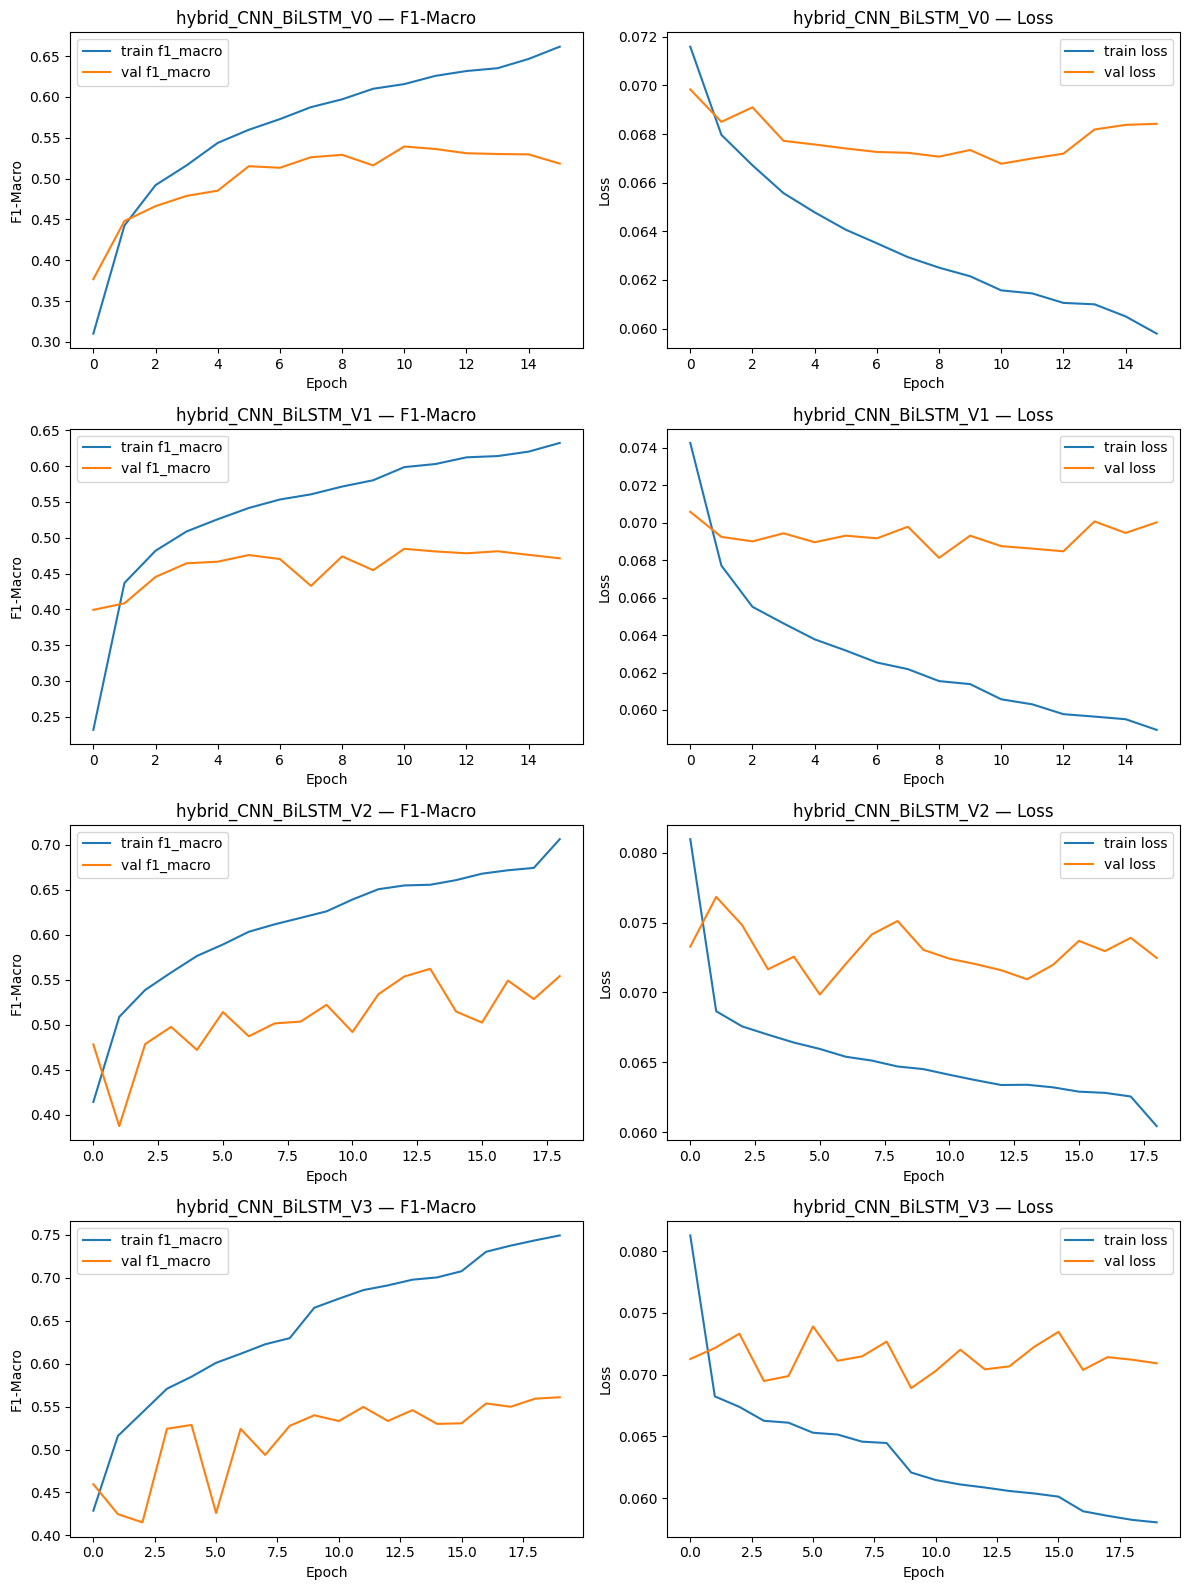


=== Test Set Evaluation ===

hybrid_CNN_BiLSTM_V0:
  loss                 0.0843
  compile_metrics      0.6589

hybrid_CNN_BiLSTM_V1:
  loss                 0.0848
  compile_metrics      0.3196

hybrid_CNN_BiLSTM_V2:
  loss                 0.3051
  compile_metrics      0.5269

hybrid_CNN_BiLSTM_V3:
  loss                 0.3197
  compile_metrics      0.5555


In [61]:
results = plot_and_evaluate(models, histories, test_dataset)

### Per-class F1-scores

In [62]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    roc_auc_score,
    hamming_loss
)

In [65]:
# dict of builders
model_builders = {
    "hybrid_CNN_BiLSTM_V0": lambda: hybrid_CNN_BiLSTM_V0((96, mean_axis_time_global, 1), num_classes=8),
    "hybrid_CNN_BiLSTM_V1": lambda: hybrid_CNN_BiLSTM_V1((96, mean_axis_time_global, 1), num_classes=8),
    "hybrid_CNN_BiLSTM_V2": lambda: hybrid_CNN_BiLSTM_V2((96, mean_axis_time_global, 1), num_classes=8),
    "hybrid_CNN_BiLSTM_V3": lambda: hybrid_CNN_BiLSTM_V3((96, mean_axis_time_global, 1), num_classes=8),
}

weight_paths = {
    "hybrid_CNN_BiLSTM_V0": "saved_models/hybrid_CNN_BiLSTM_V0.keras",
    "hybrid_CNN_BiLSTM_V1": "saved_models/hybrid_CNN_BiLSTM_V1.keras",
    "hybrid_CNN_BiLSTM_V2": "saved_models/hybrid_CNN_BiLSTM_V2.keras",
    "hybrid_CNN_BiLSTM_V3": "saved_models/hybrid_CNN_BiLSTM_V3.keras",
}

In [66]:
def compile_model(model, lr=1e-3, clipnorm=1.0):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr, clipnorm=clipnorm),
        loss=weighted_focal_loss_with_weights,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(threshold=0.5, name="acc"),
            tf.keras.metrics.F1Score(threshold=0.5, average="micro", name="f1_micro"),
            tf.keras.metrics.F1Score(threshold=0.5, average="macro", name="f1_macro"),
        ]
    )

In [67]:
per_genre_rows = []
overall_rows    = []
genre_names = ['LAIKO','REMPETIKO','ENTEXNO','ROCK','Mod LAIKO','POP','ENALLAKTIKO','HIPHOP/RNB']

for name, build_fn in model_builders.items():
    model = build_fn()
    model.load_weights(weight_paths[name])
    compile_model(model)

    # gather all true and predicted
    all_true = []
    all_proba= []
    for x_b, y_b in test_dataset:
        all_true.append(y_b.numpy())
        all_proba.append(model.predict(x_b, verbose=0))
    y_true  = np.vstack(all_true)
    y_proba = np.vstack(all_proba)
    y_pred  = (y_proba > 0.5).astype(int)

    # per-genre metrics
    for i, genre in enumerate(genre_names):
        p, r, f1, _ = precision_recall_fscore_support(
            y_true[:,i], y_pred[:,i], average='binary', zero_division=0
        )
        acc = accuracy_score(y_true[:,i], y_pred[:,i])
        auc = roc_auc_score(y_true[:,i], y_proba[:,i])
        per_genre_rows.append({
            "Model": name,
            "Genre": genre,
            "Precision": p,
            "Recall":    r,
            "F1":        f1,
            "Accuracy":  acc,
            "AUC":       auc
        })

    # overall metrics
    flat_pred = y_pred.flatten()
    flat_true = y_true.flatten()
    prec, rec, f1, _ = precision_recall_fscore_support(
        flat_true, flat_pred, average='binary', zero_division=0
    )
    acc = accuracy_score(flat_true, flat_pred)
    ham = hamming_loss(y_true, y_pred)
    exact = np.mean(np.all(y_true == y_pred, axis=1))
    overall_rows.append({
        "Model":           name,
        "Precision":       prec,
        "Recall":          rec,
        "F1":              f1,
        "Accuracy":        acc,
        "Hamming Loss":    ham,
        "Exact Match %":   exact
    })


=== Evaluating hybrid_CNN_BiLSTM_V0 ===

=== Evaluating hybrid_CNN_BiLSTM_V1 ===

=== Evaluating hybrid_CNN_BiLSTM_V2 ===

=== Evaluating hybrid_CNN_BiLSTM_V3 ===


In [68]:
df_genre = pd.DataFrame(per_genre_rows).set_index(["Model","Genre"])
df_overall = pd.DataFrame(overall_rows).set_index("Model")

print("\nPer-genre metrics:")
display(df_genre)

print("\nOverall metrics:")
display(df_overall)


Per-genre metrics:


Precision    Recall        F1  Accuracy  \
Model                Genre                                                  
hybrid_CNN_BiLSTM_V0 LAIKO         0.756298  0.602268  0.670551  0.788267   
                     REMPETIKO     0.606977  0.734177  0.664545  0.917772   
                     ENTEXNO       0.628453  0.455228  0.527995  0.746138   
                     ROCK          0.546218  0.662139  0.598619  0.836792   
                     Mod LAIKO     0.669799  0.482592  0.560989  0.756280   
                     POP           0.255922  0.830035  0.391221  0.653768   
                     ENALLAKTIKO   0.346886  0.816869  0.486976  0.646591   
                     HIPHOP/RNB    0.633508  0.728916  0.677871  0.964113   
hybrid_CNN_BiLSTM_V1 LAIKO         0.737293  0.563018  0.638477  0.771883   
                     REMPETIKO     0.675307  0.696203  0.685596  0.929162   
                     ENTEXNO       0.585353  0.567784  0.576435  0.739741   
                     ROCK          0.532475  0.807301  0.641700  0.834296   
                     Mod LAIKO     0.000000  0.000000  0.000000  0.677173   
                     POP           0.254478  0.793946  0.385420  0.660633   
                     ENALLAKTIKO   0.358392  0.778875  0.490900  0.668279   
                     HIPHOP/RNB    0.686620  0.587349  0.633117  0.964737   
hybrid_CNN_BiLSTM_V2 LAIKO         0.765646  0.730920  0.747880  0.823685   
                     REMPETIKO     0.651515  0.665260  0.658316  0.923389   
                     ENTEXNO       0.608222  0.503252  0.550780  0.743954   
                     ROCK          0.439252  0.877759  0.585504  0.771571   
                     Mod LAIKO     0.702818  0.397969  0.508182  0.751443   
                     POP           0.346512  0.693830  0.462195  0.783586   
                     ENALLAKTIKO   0.350255  0.886018  0.502045  0.639101   
                     HIPHOP/RNB    0.708904  0.623494  0.663462  0.967234   
hybrid_CNN_BiLSTM_V3 LAIKO         0.784438  0.593546  0.675770  0.796224   
                     REMPETIKO     0.719243  0.641350  0.678067  0.932439   
                     ENTEXNO       0.561331  0.540270  0.550599  0.724918   
                     ROCK          0.564468  0.806452  0.664103  0.850055   
                     Mod LAIKO     0.629675  0.496615  0.555285  0.743330   
                     POP           0.322350  0.523865  0.399113  0.788579   
                     ENALLAKTIKO   0.368543  0.845745  0.513376  0.670775   
                     HIPHOP/RNB    0.613527  0.765060  0.680965  0.962865   

                                       AUC  
Model                Genre                  
hybrid_CNN_BiLSTM_V0 LAIKO        0.847963  
                     REMPETIKO    0.941669  
                     ENTEXNO      0.794126  
                     ROCK         0.872523  
                     Mod LAIKO    0.818058  
                     POP          0.778519  
                     ENALLAKTIKO  0.755965  
                     HIPHOP/RNB   0.882539  
hybrid_CNN_BiLSTM_V1 LAIKO        0.832615  
                     REMPETIKO    0.901799  
                     ENTEXNO      0.792349  
                     ROCK         0.892848  
                     Mod LAIKO    0.469253  
                     POP          0.772224  
                     ENALLAKTIKO  0.753892  
                     HIPHOP/RNB   0.875980  
hybrid_CNN_BiLSTM_V2 LAIKO        0.877812  
                     REMPETIKO    0.928086  
                     ENTEXNO      0.782762  
                     ROCK         0.894082  
                     Mod LAIKO    0.789009  
                     POP          0.805030  
                     ENALLAKTIKO  0.769533  
                     HIPHOP/RNB   0.863315  
hybrid_CNN_BiLSTM_V3 LAIKO        0.850345  
                     REMPETIKO    0.911553  
                     ENTEXNO      0.765839  
                     ROCK         0.903765  
                     Mod LAIKO    0.794781  
                    


Overall metrics:


,Precision,Recall,F1,Accuracy,Hamming Loss,Exact Match %
Model,,,,,,
hybrid_CNN_BiLSTM_V0,0.497109,0.615563,0.550031,0.788715,0.211285,0.163208
hybrid_CNN_BiLSTM_V1,0.479807,0.536817,0.506713,0.780738,0.219262,0.153378
hybrid_CNN_BiLSTM_V2,0.519613,0.649033,0.577157,0.800495,0.199505,0.199407
hybrid_CNN_BiLSTM_V3,0.537991,0.622071,0.576984,0.808648,0.191352,0.193322


In [69]:
# Confusion matrix for multi-label classification
print("\nLabel correlation analysis:")
print("Analyzing how well the model captures label relationships...")

# correlation matrices for true labels and predictions
true_corr = np.corrcoef(y_true.T)
pred_corr = np.corrcoef(y_pred.T)

# mean absolute error between correlation matrices
corr_mae = np.abs(true_corr - pred_corr).mean()
print(f"Correlation Matrix MAE: {corr_mae:.3f}")


Label correlation analysis:
Analyzing how well the model captures label relationships...
Correlation Matrix MAE: 0.077


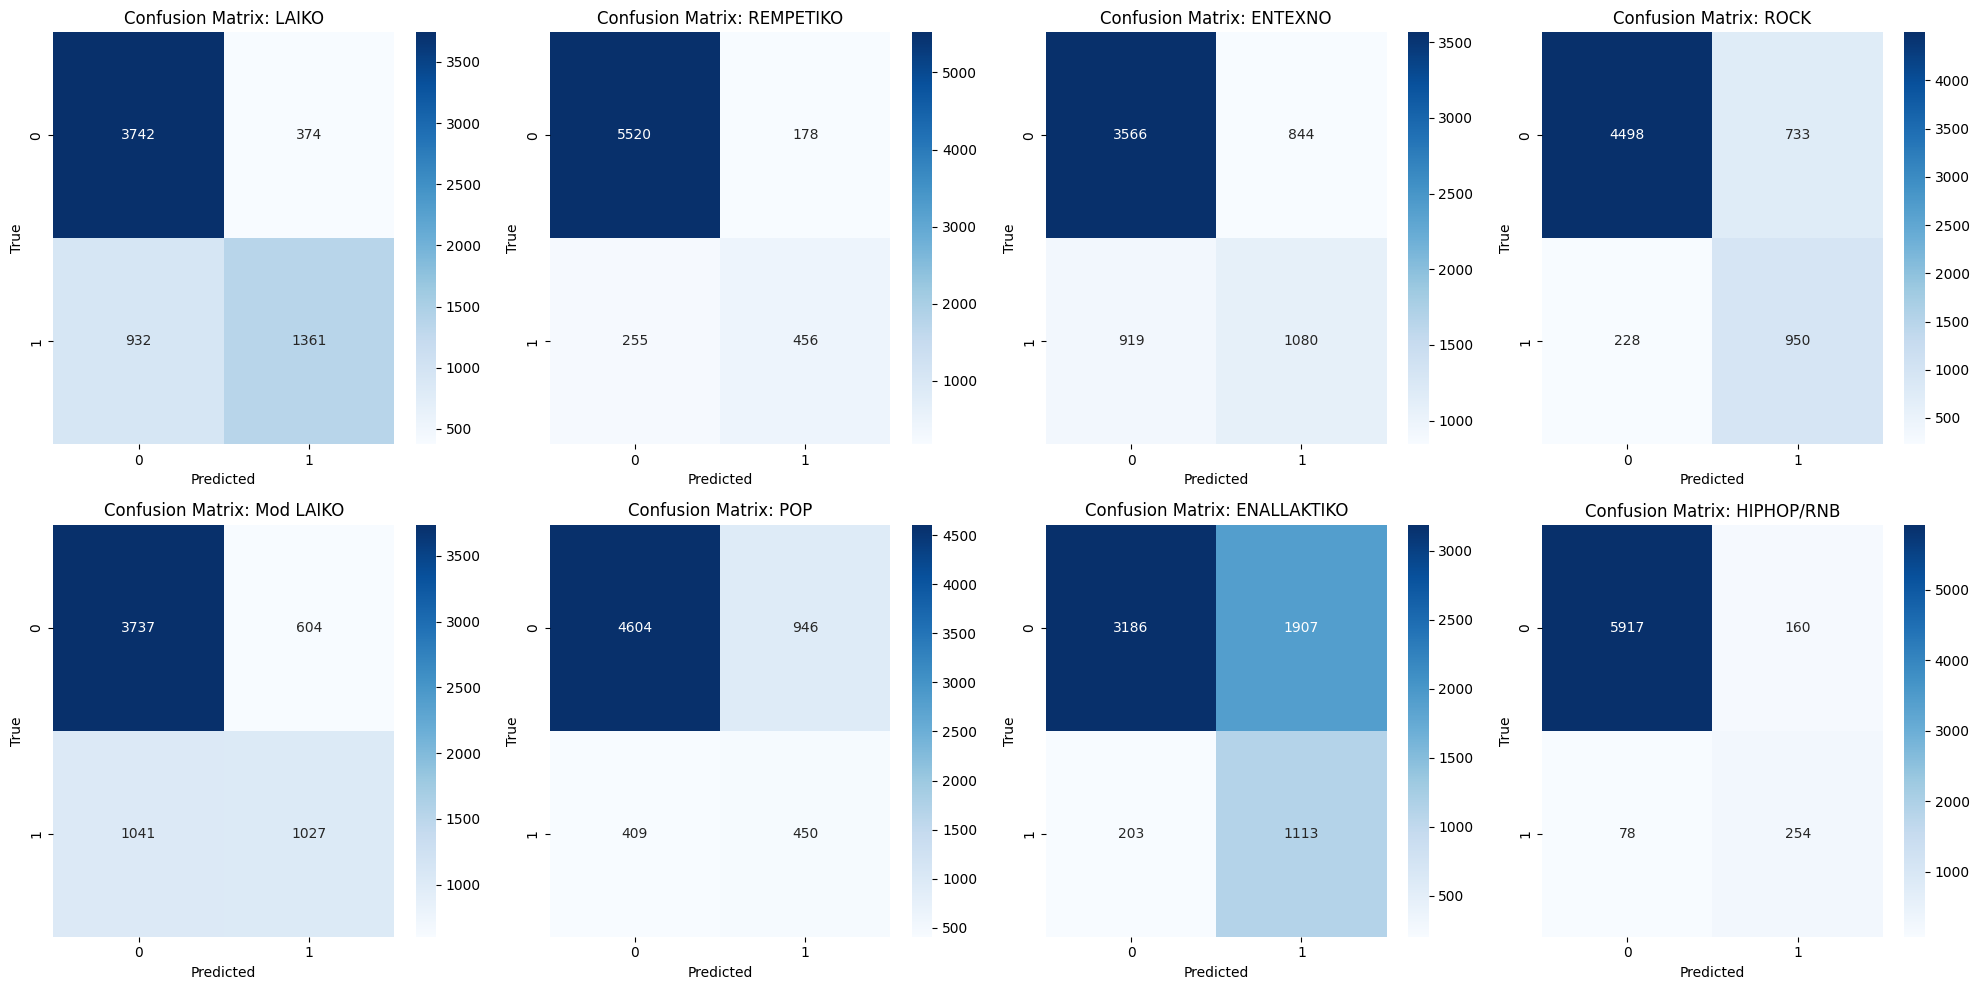

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix for each genre
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
cms = []

for i, (genre, ax) in enumerate(zip(genre_names, axes)):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    cms.append(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix: {genre}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    
plt.tight_layout()
plt.show();

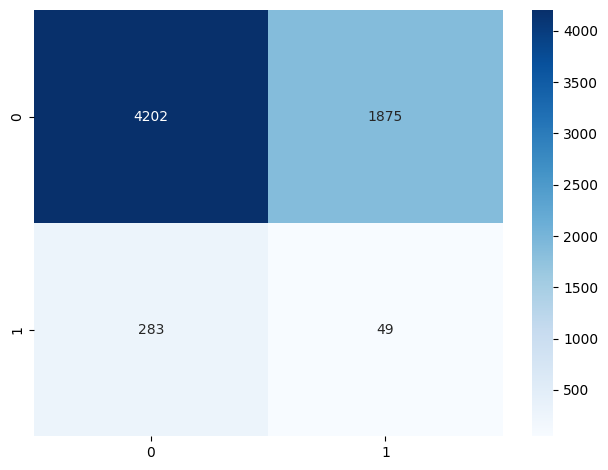

In [71]:
cm = tf.math.confusion_matrix(y_true[:,7], y_pred[:,2])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
ax.set_title(f'Confusion Matrix: {genre}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout() 
plt.show();

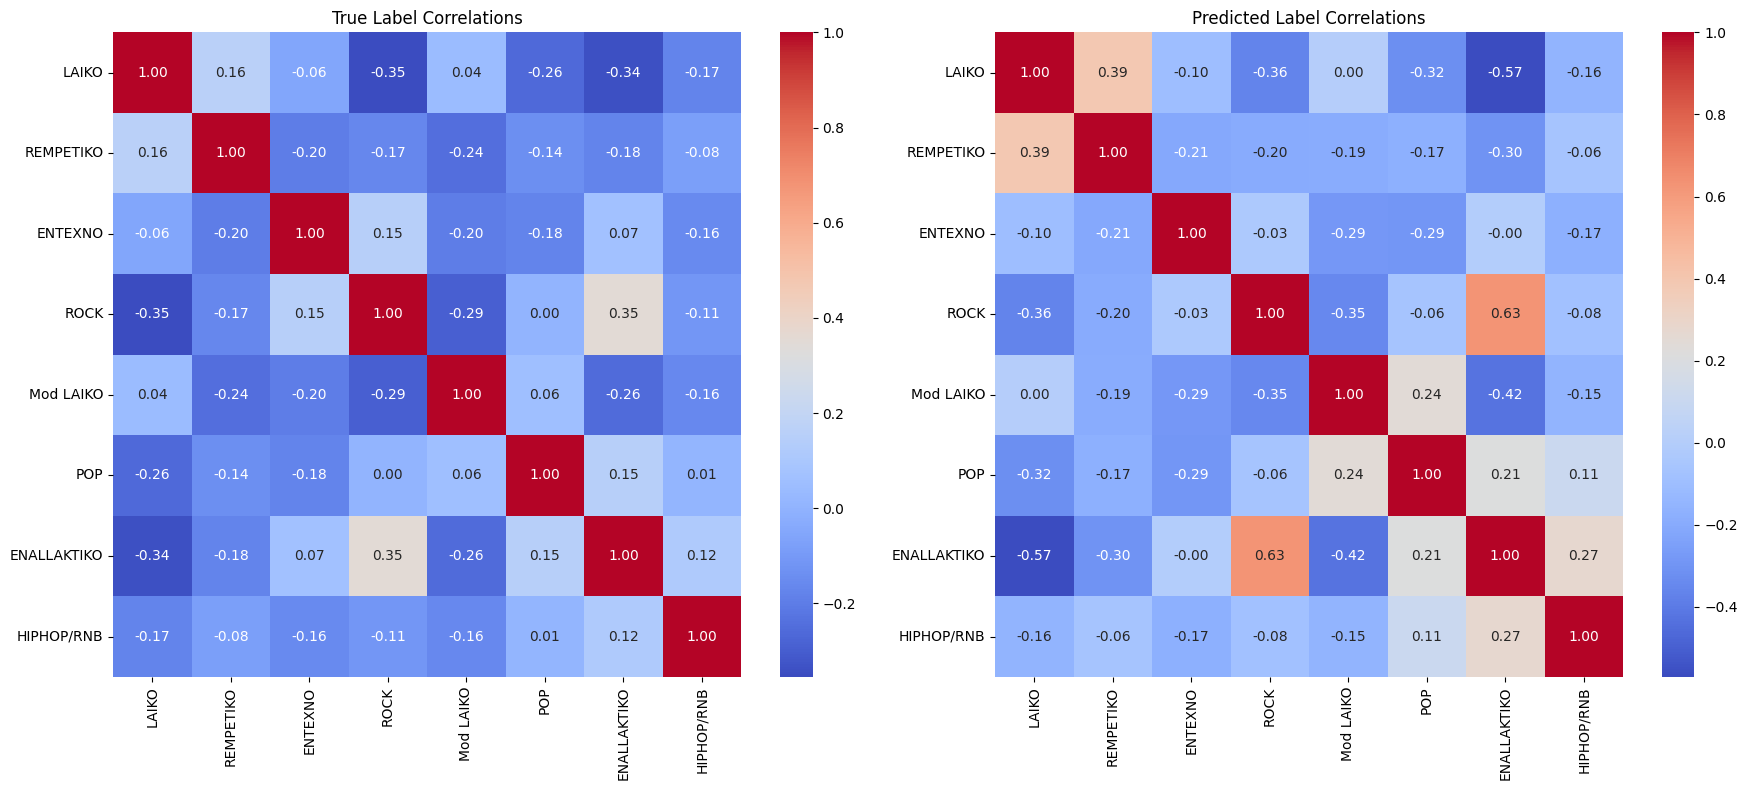

In [72]:
# correlation matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(true_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax1, 
            xticklabels=genre_names, yticklabels=genre_names)
ax1.set_title('True Label Correlations')

sns.heatmap(pred_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, 
            xticklabels=genre_names, yticklabels=genre_names)
ax2.set_title('Predicted Label Correlations')

plt.tight_layout()
plt.show();

### Visualising the embedding space

In [73]:
model.summary()

Model: "hybrid_CNN_BiLSTM_V3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 96, 432,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_15 (Cast)      │ (None, 96, 432,   │          0 │ input_layer_12[0… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 96, 432,   │        288 │ cast_15[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 432,   │        128 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 96, 432,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 48, 108,   │          0 │ activation_37[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 48, 108,   │     18,496 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 48, 108,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 48, 108,   │          0 │ activation_38[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 48, 108,   │     36,928 │ dropout_55[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 48, 108,   │      2,112 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 48, 108,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_65[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 48, 108,   │          0 │ add_17[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 24, 36,    │          0 │ activation_39[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 12, 18,    │     55,392 │ max_pooling2d_21

 Total params: 1,106,427 (4.22 MB)

 Trainable params: 1,104,187 (4.21 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [74]:
# Create a new model that outputs only the dense embeddings
embedding_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("dense_29").output)

# Get the embeddings
dense_embeddings = embedding_model.predict(test_dataset, batch_size=16)

101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [75]:
dense_embeddings.shape

(6409, 128)

In [76]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_results = TSNE(n_components=2, perplexity=30).fit_transform(dense_embeddings)

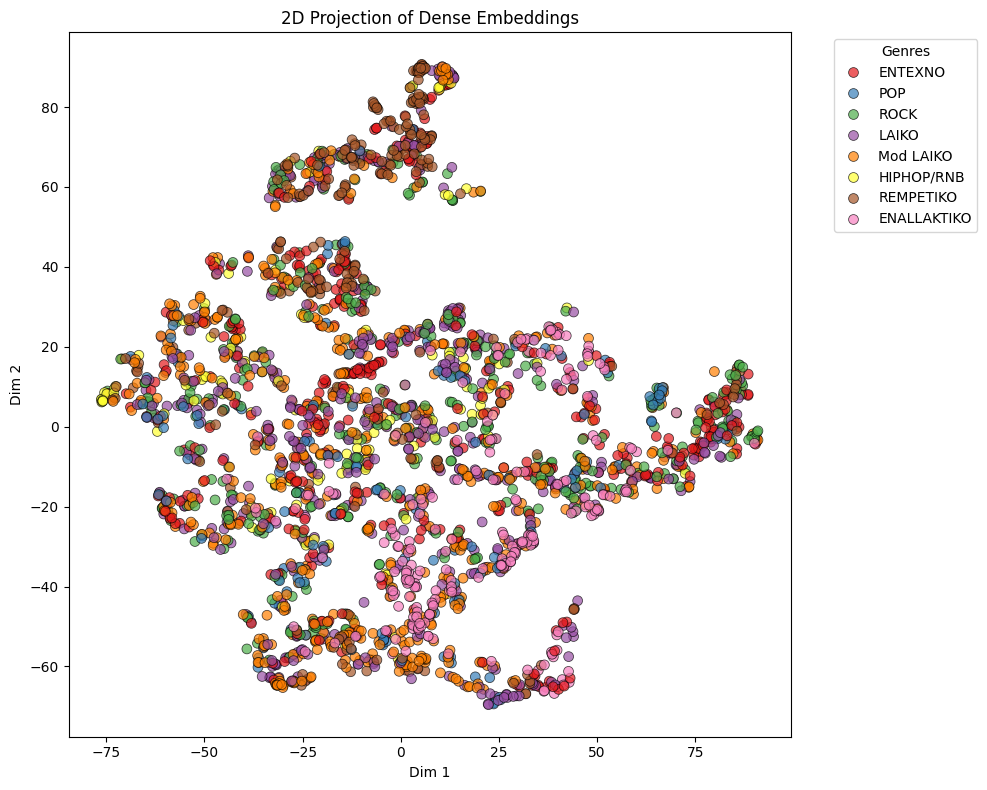

In [77]:
# Get most prominent label for coloring with argmax
single_label_mask = np.sum(y_true, axis=1) == 1
x_embedded_filtered = tsne_results[single_label_mask]
y_labels = np.argmax(y_true[single_label_mask], axis=1)

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", len(np.unique(y_labels)))

genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']
y_labels_named = [genre_names[i] for i in y_labels]

sns.scatterplot(
    x=x_embedded_filtered[:, 0],
    y=x_embedded_filtered[:, 1],
    hue=y_labels_named,
    palette="Set1",  # updated for better color contrast
    alpha=0.7,
    s=50,
    edgecolor='k'
)


plt.title("2D Projection of Dense Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


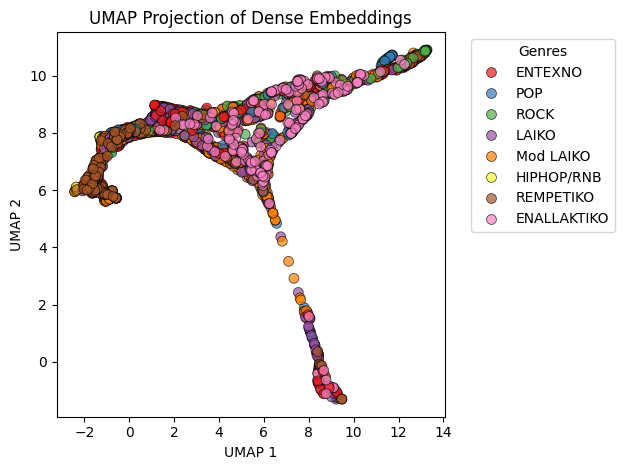

In [78]:
import umap.umap_ as umap

reducer = umap.UMAP(n_components=6, random_state=42)
umap_results = reducer.fit_transform(dense_embeddings)

sns.scatterplot(
    x=umap_results[single_label_mask][:, 0],
    y=umap_results[single_label_mask][:, 1],
    hue=y_labels_named,
    palette="Set1",
    alpha=0.7,
    s=50,
    edgecolor='k'
)
plt.title("UMAP Projection of Dense Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Explained variance ratio: [0.33660924 0.25347808 0.15137157 0.11469961 0.0737339  0.03437737]


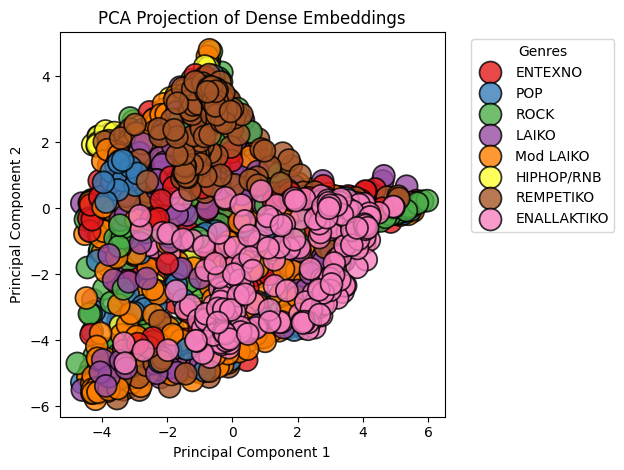

In [79]:
from sklearn.decomposition import PCA

pca = PCA(n_components=6)
pca_results = pca.fit_transform(dense_embeddings)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")  # see how much info is preserved

sns.scatterplot(
    x=pca_results[single_label_mask][:, 0],
    y=pca_results[single_label_mask][:, 1],
    hue=y_labels_named,
    palette="Set1",
    alpha=0.8,
    s=250,
    edgecolor='k'
)
plt.title("PCA Projection of Dense Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();

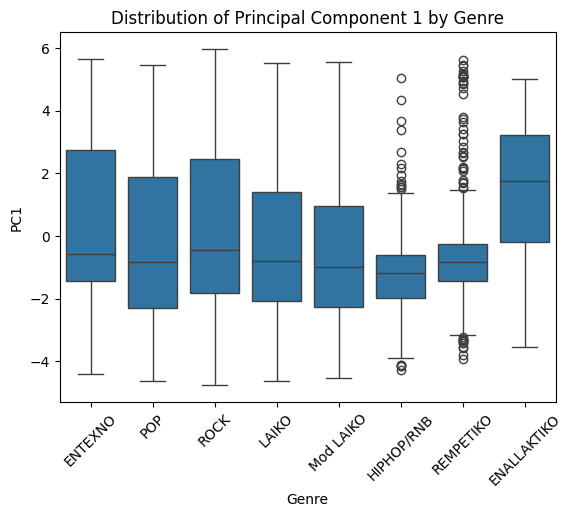

In [80]:
pca_1 = pca_results[single_label_mask][:, 0]

df = pd.DataFrame({
    'PC1': pca_1,
    'Genre': y_labels_named
})

sns.boxplot(data=df, x='Genre', y='PC1')
plt.xticks(rotation=45)
plt.title("Distribution of Principal Component 1 by Genre")
plt.show()

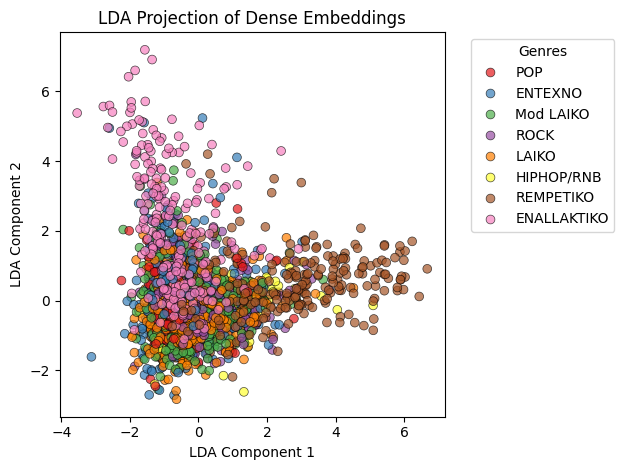

In [170]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
dense_embeddings_filtered = dense_embeddings[single_label_mask]

lda = LDA(n_components=6)
lda_results = lda.fit_transform(dense_embeddings_filtered, y_labels)

sns.scatterplot(
    x=lda_results[:, 0],
    y=lda_results[:, 1],
    hue=y_labels_named,
    palette="Set1",
    alpha=0.7,
    s=40,
    edgecolor='k'
)
plt.title("LDA Projection of Dense Embeddings")
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [80]:
optimal_thresholds

[0.3, 0.85, 0.15, 0.85, 0.45, 0.45, 0.1, 0.3]

In [81]:
i = 0
found_better = False
for best_thresh in optimal_thresholds:
    for thresh in np.arange(max(0.05, best_thresh - 0.05), min(0.95, best_thresh + 0.05), 0.01):
        f1 = f1_score(val_labels[:, genre], val_preds[1][:, genre] > thresh)
        if f1 > best_f1:
            best_f1, best_thresh_finetuned = f1, thresh
            found_better = True
    if found_better:
        optimal_thresholds[i] = best_thresh_finetuned
    found_better = False
    i += 1

In [82]:
optimal_thresholds

[0.27, 0.85, 0.15, 0.85, 0.45, 0.45, 0.1, 0.3]

In [83]:
optimal_thresholds = [0.5]*8

In [84]:
# Get predictions from the test dataset
y_pred = model.predict(test_dataset)  # Shape: [2, num_samples, ...]
binary_preds = y_pred[1]  # Shape: [num_samples, 8]

# Convert to binary predictions using per-genre thresholds
thresholds_array = np.array(optimal_thresholds)  # Shape: [8]
binary_predictions = (binary_preds > thresholds_array).astype(int)  # Shape: [num_samples, 8]

71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [85]:
y_true = np.concatenate([y['binary_output'].numpy() for _, y in test_dataset.take(71)])  # Shape: [num_samples, 8]

# Compute macro F1 score
macro_f1 = f1_score(y_true, binary_predictions, average='macro')
print(f"Macro F1 Score with optimal thresholds: {macro_f1}")

# Optionally, per-genre F1 scores
per_genre_f1 = [f1_score(y_true[:, i], binary_predictions[:, i]) for i in range(8)]
for i, f1 in enumerate(per_genre_f1):
    print(f"Genre {i}: F1 = {f1}")

Macro F1 Score with optimal thresholds: 0.6044594492038253
Genre 0: F1 = 0.7118535175072278
Genre 1: F1 = 0.7019064124783362
Genre 2: F1 = 0.5627575871112777
Genre 3: F1 = 0.6646736422521176
Genre 4: F1 = 0.6296607793664144
Genre 5: F1 = 0.4433734939759036
Genre 6: F1 = 0.4562233790818741
Genre 7: F1 = 0.6652267818574514


In [86]:
y_true[0] #genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']

array([0, 0, 0, 1, 0, 0, 1, 0])

In [87]:
y_pred[0]

array([[ 0.5454 , -0.1489 ,  0.769  ,  0.2272 ,  0.1527 ,  0.1176 ],
       [ 0.3823 ,  0.7954 , -0.04266, -0.2384 ,  0.3948 ,  0.08215],
       [ 0.359  ,  0.5117 ,  0.521  , -0.427  , -0.3845 ,  0.0895 ],
       ...,
       [ 0.4316 ,  0.3389 ,  0.665  , -0.2441 , -0.4346 ,  0.0874 ],
       [ 0.6787 , -0.0902 , -0.2715 , -0.502  , -0.0671 , -0.4495 ],
       [ 0.6094 , -0.2357 ,  0.721  ,  0.1554 ,  0.1539 ,  0.065  ]],
      dtype=float16)

In [88]:
#optimal_thresholds = [0.16, 0.27, 0.07, 0.89, 0.997, 0.988, 1.0, 0.77]
optimal_thresholds = [0.27, 0.85, 0.15, 0.85, 0.45, 0.45, 0.1, 0.3]
thresholds_array = np.array(optimal_thresholds)
#genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']
# Apply to predictions
binary_predictions = (binary_preds > thresholds_array).astype(int)

# Then recompute EM:
em_ratio = np.mean(np.all(binary_predictions == y_true, axis=1))
print(f"Exact Match (EM) Ratio with optimal thresholds: {em_ratio:.4f}")

Exact Match (EM) Ratio with optimal thresholds: 0.1981


In [90]:
optimal_thresholds = [0.5]*8
thresholds_array = np.array(optimal_thresholds)
#genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']
# Apply to predictions
binary_predictions = (binary_preds > thresholds_array).astype(int)

# Then recompute EM:
em_ratio = np.mean(np.all(binary_predictions == y_true, axis=1))
print(f"Exact Match (EM) Ratio with optimal thresholds: {em_ratio:.4f}")

Exact Match (EM) Ratio with optimal thresholds: 0.2276


In [91]:
#the thresholds that are optimal for f1 scores are not also optimal for EM